# Ampliación del tracker de Lucas-Kanade: movimiento de la cámara

Ampliamos `code/LK/lk_track.py` para, a partir del campo de desplazamientos
de los puntos seguidos entre dos fotogramas consecutivos:

a) determinar en qué dirección se mueve la cámara
   (`UP`, `DOWN`, `LEFT`, `RIGHT`, `FORWARD`, `BACKWARD`)
b) estimar la velocidad angular de rotación de la cámara (grados/segundo)

## Planteamiento

A partir de los desplazamientos `v = p1 - p0` de los puntos seguidos entre dos fotogramas se calculan tres cosas:

- **Traslación** (`mean_flow = media(v)`): el fondo se mueve en bloque en sentido contrario a la cámara. La componente dominante da `LEFT/RIGHT/UP/DOWN`.

- **Expansión radial** (`media(v · r̂)`, con `r = p0 - centro`): si la cámara avanza el flujo se expande desde el centro (FORWARD), si retrocede se contrae (BACKWARD).

- **Rotación** (`omega = media(cross(r, v) / |r|²)`): para un giro sobre el eje óptico se cumple `v = ω × r`, así que esto da la velocidad angular en rad/fotograma (×fps → rad/s).

La que domine (escalando todo a px/fotograma) determina la clasificación. Por debajo de `MINFLOW`: sin movimiento detectado.

## Comprobación con `images/rot4.mjpg`

Antes de probarlo con la cámara en directo, comprobamos que la estimación de
`omega` (velocidad angular) funciona correctamente con el vídeo
`images/rot4.mjpg`, que muestra una escena plana vista por una cámara que
gira sobre su eje óptico.

363 de 412 fotogramas clasificados como rotación
omega media: 0.217 grados/fotograma (sentido horario si > 0)


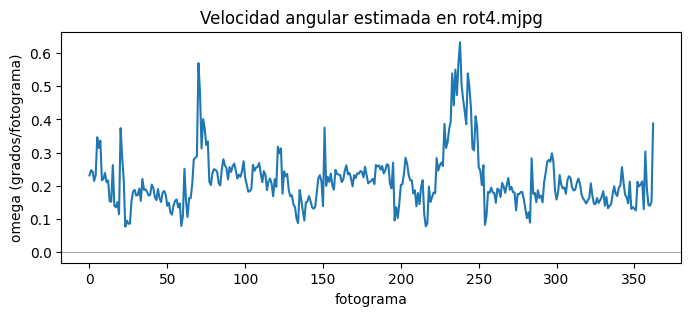

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

cap = cv.VideoCapture('../../images/rot4.mjpg')

tracks = []
track_len = 20
detect_interval = 5

corners_params = dict(maxCorners=500, qualityLevel=0.1, minDistance=10, blockSize=7)
lk_params = dict(winSize=(15,15), maxLevel=2,
                  criteria=(cv.TERM_CRITERIA_EPS | cv.TERM_CRITERIA_COUNT, 10, 0.03))

MINFLOW = 0.5
omegas = []  # grados/fotograma, cuando la rotación es el movimiento dominante

n = 0
prevgray = None
while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    h, w = gray.shape
    center = np.array([w/2, h/2])
    R = np.hypot(w,h)/2

    if tracks:
        p0 = np.float32([t[-1] for t in tracks])
        p1, _, _ = cv.calcOpticalFlowPyrLK(prevgray, gray, p0, None, **lk_params)
        p0r, _, _ = cv.calcOpticalFlowPyrLK(gray, prevgray, p1, None, **lk_params)
        d = abs(p0-p0r).reshape(-1,2).max(axis=1)
        good = d < 1
        new_tracks, flows = [], []
        for t, p_old, p_new, ok in zip(tracks, p0, p1.reshape(-1,2), good):
            if not ok: continue
            t.append(p_new)
            new_tracks.append(t)
            flows.append((p_old, p_new-p_old))
        tracks = new_tracks

        if len(flows) >= 10:
            p0s = np.array([p for p,_ in flows])
            vs  = np.array([v for _,v in flows])
            mean_flow = vs.mean(axis=0)
            r = p0s - center
            rn = r / np.linalg.norm(r, axis=1, keepdims=True).clip(1e-3)
            expansion = np.mean(np.sum(vs*rn, axis=1))
            cross = r[:,0]*vs[:,1] - r[:,1]*vs[:,0]
            r2 = np.sum(r*r, axis=1).clip(1.0)
            omega = np.mean(cross/r2)
            mags = {'trans': np.linalg.norm(mean_flow), 'exp': abs(expansion), 'rot': abs(omega)*R}
            best = max(mags, key=mags.get)
            if mags[best] >= MINFLOW and best == 'rot':
                omegas.append(np.degrees(omega))

    if n % detect_interval == 0:
        mask = np.zeros_like(gray)
        mask[:] = 255
        for x,y in [np.int32(t[-1]) for t in tracks]:
            cv.circle(mask,(x,y),5,0,-1)
        corners = cv.goodFeaturesToTrack(gray, mask=mask, **corners_params)
        if corners is not None:
            for [pt] in np.float32(corners):
                tracks.append(deque([pt], maxlen=track_len))

    prevgray = gray
    n += 1

print(f'{len(omegas)} de {n} fotogramas clasificados como rotación')
print(f'omega media: {np.mean(omegas):.3f} grados/fotograma (sentido horario si > 0)')

plt.figure(figsize=(8,3))
plt.plot(omegas)
plt.axhline(0, color='gray', lw=0.5)
plt.xlabel('fotograma')
plt.ylabel('omega (grados/fotograma)')
plt.title('Velocidad angular estimada en rot4.mjpg')
plt.show()

La rotación estimada es consistentemente positiva (sentido horario) en el
89% de los fotogramas, con `omega` medio ≈ 0.22 grados/fotograma. A 25 fps
eso equivale a una rotación de la cámara de unos 5.4°/s, coherente con un
giro lento y sostenido como el de `rot4.mjpg`.

## `lk_motion.py`: en directo

```
./lk_motion.py --dev=0
```

Muestra las trayectorias de los puntos seguidos (`d` para ocultarlas), una flecha con la dirección del flujo medio, y en la esquina la clasificación: `LEFT/RIGHT/UP/DOWN`, `FORWARD/BACKWARD`, rotación horario/antihorario con velocidad en °/s, o sin movimiento detectado.